# Day 10 — Machine Learning Practice: Linear Regression
**Linkific AI/ML Internship**

---

## 1. Day 10 Objective

The objective of Day 10 is to introduce foundational Machine Learning concepts and build a hands-on end-to-end regression workflow:
- Understand how Machine Learning works in contrast to rule-based programming.
- Learn the standard ML pipeline: data ingestion, feature selection, train-test splitting, model training, prediction, evaluation, and visualization.
- Implement a simple, clean, and beginner-friendly **Linear Regression** model using **Scikit-learn** on a dataset of Years of Experience vs. Salary.
- Understand and interpret model parameters (slope, intercept) and evaluation metrics ($R^2$ score).
- Practice the complete flow from raw data to actionable prediction.

## 2. Machine Learning Workflow

A typical supervised Machine Learning project follows a structured nine-step sequence:

1. **Load data:** Ingest raw dataset into memory.
2. **Understand data:** Inspect shape, column types, distributions, and check for missing values.
3. **Select features and target:** Identify input predictor ($X$) and target outcome ($y$).
4. **Prepare data:** Verify proper data types and ensure no missing values exist.
5. **Split data:** Partition observations into separate training (80%) and testing (20%) sets.
6. **Train model:** Allow the algorithm to learn the mathematical linear relationship (`.fit()`).
7. **Make predictions:** Generate estimated values on unseen test records (`.predict()`).
8. **Evaluate/inspect predictions:** Compare predicted outputs against actual ground truth using $R^2$ score.
9. **Interpret results:** Understand the learned equation parameters (slope and intercept).

### Key Definitions
- **Feature ($X$):** The input variable used by the model to make a prediction (`YearsExperience`).
- **Target ($y$):** The value the model is trying to predict (`Salary`).
- **Training Data:** The portion of data (80%) used by the algorithm to adjust internal weights.
- **Testing Data:** The unseen portion (20%) reserved exclusively to check how the model generalizes.
- **Model:** The algorithm that learns the linear relationship between $X$ and $y$.
- **Prediction:** The numerical output ($\hat{y}$) generated by the trained model.


In [1]:
import os
import sys
import pandas as pd
import matplotlib.pyplot as plt
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

print("Required libraries imported successfully.")


Required libraries imported successfully.


In [2]:
print("Python Version:", sys.version.split()[0])
print("Scikit-learn Version:", sklearn.__version__)


Python Version: 3.14.3
Scikit-learn Version: 1.9.0


In [3]:
# Load the small beginner-friendly dataset (Years of Experience vs Salary)
dataset_path = "Day-10/salary_data.csv"
if not os.path.exists(dataset_path):
    dataset_path = "salary_data.csv"

df = pd.read_csv(dataset_path)
print(f"Dataset successfully loaded from: {dataset_path}")


Dataset successfully loaded from: Day-10/salary_data.csv


In [4]:
print(f"Dataset Shape: {df.shape[0]} rows, {df.shape[1]} columns\n")
print("Missing values count per column:")
print(df.isnull().sum())
print("\nFirst 5 rows:")
df.head(5)


Dataset Shape: 30 rows, 2 columns

Missing values count per column:
YearsExperience    0
Salary             0

First 5 rows:


,YearsExperience,Salary
0,1.1,39343
1,1.3,46205
2,1.5,37731
3,2.0,43525
4,2.2,39891


In [5]:
# Verify data types and absence of null values
print("Dataset Information:")
print(df.info())
print("\nSummary Statistics:")
df.describe()


Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   YearsExperience  30 non-null     float64
 1   Salary           30 non-null     int64  
dtypes: float64(1), int64(1)
memory usage: 612.0 bytes
None

Summary Statistics:


,YearsExperience,Salary
count,30.000000,30.000000
mean,5.313333,76003.000000
std,2.837888,27414.429785
min,1.100000,37731.000000
25%,3.200000,56720.750000
50%,4.700000,65237.000000
75%,7.700000,100544.750000
max,10.500000,122391.000000


In [6]:
# Define Feature matrix (X) and Target vector (y)
X = df[["YearsExperience"]]
y = df["Salary"]

print(f"Total samples: {len(df)}")
print(f"Feature matrix (X) shape: {X.shape}")
print(f"Target vector  (y) shape: {y.shape}")
print(f"Experience range: {X['YearsExperience'].min()} to {X['YearsExperience'].max()} years")
print(f"Salary range:     ${y.min():,.2f} to ${y.max():,.2f}")


Total samples: 30
Feature matrix (X) shape: (30, 1)
Target vector  (y) shape: (30,)
Experience range: 1.1 to 10.5 years
Salary range:     $37,731.00 to $122,391.00


In [7]:
# Split data: 80% for training, 20% for testing
# random_state=42 guarantees reproducible partitions
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training samples (X_train): {len(X_train)} (80%)")
print(f"Testing samples  (X_test):  {len(X_test)} (20%)")
print("Partitioning verified and reproducible.")


Training samples (X_train): 24 (80%)
Testing samples  (X_test):  6 (20%)
Partitioning verified and reproducible.


In [8]:
# Instantiate a simple Linear Regression model
model = LinearRegression()
print("Model initialized successfully:")
print(model)


Model initialized successfully:
LinearRegression()


In [9]:
# Train the model on training data using .fit()
model.fit(X_train, y_train)
print("Model training completed successfully.")


Model training completed successfully.


In [10]:
# Make predictions on unseen test data using .predict()
y_pred = model.predict(X_test)
print(f"Successfully generated {len(y_pred)} predictions on the test dataset.")


Successfully generated 6 predictions on the test dataset.


In [11]:
# Create a clean comparison table of actual vs. predicted values
results = pd.DataFrame({
    "Years Experience": X_test["YearsExperience"].values,
    "Actual Salary ($)": y_test.values,
    "Predicted Salary ($)": y_pred.round(2),
    "Residual Error ($)": (y_test.values - y_pred).round(2)
})

print("Prediction Results on Unseen Test Records:")
results


Prediction Results on Unseen Test Records:


Years Experience,Actual Salary ($),Predicted Salary ($),Residual Error ($)
9.6,112635,115790.21,-3155.21
4.9,67938,71498.28,-3560.28
8.2,113812,102596.87,11215.13
5.3,83088,75267.80,7820.20
3.2,64445,55477.79,8967.21
3.7,57189,60189.70,-3000.70


In [12]:
# Extract the learned slope (coefficient) and intercept
slope = model.coef_[0]
intercept = model.intercept_

print(f"Slope (Coefficient, m): ${slope:,.2f}")
print(f"Intercept (b):           ${intercept:,.2f}")
print(f"\nLinear Equation: Salary = (${slope:,.2f} * YearsExperience) + ${intercept:,.2f}")


Slope (Coefficient, m): $9,423.82
Intercept (b):           $25,321.58

Linear Equation: Salary = ($9,423.82 * YearsExperience) + $25,321.58


In [13]:
# Calculate the R² (Coefficient of Determination) score
r2 = r2_score(y_test, y_pred)
print(f"R² Score on Test Data: {r2:.4f}")
print(f"Interpretation: {r2 * 100:.1f}% of the variance in salary is explained by years of experience.")


R² Score on Test Data: 0.9024
Interpretation: 90.2% of the variance in salary is explained by years of experience.


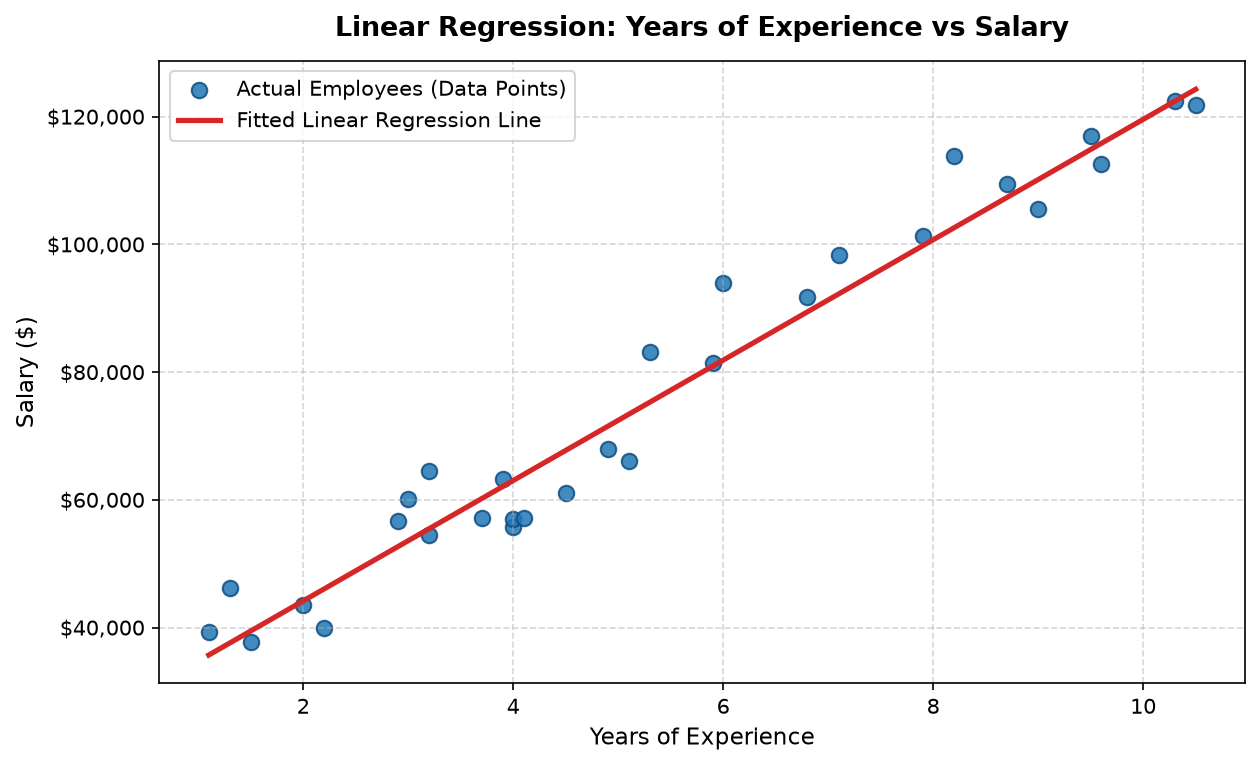

In [14]:
# Create a clean scatter plot of actual data points and fitted regression line
plt.figure(figsize=(8.5, 5.2), dpi=150)

# Scatter plot of actual observations
plt.scatter(
    X["YearsExperience"], y,
    color="#1f77b4", s=55, alpha=0.85, edgecolors="#0f4c81",
    label="Actual Employees (Data Points)"
)

# Plot fitted regression line
sorted_exp = pd.DataFrame({"YearsExperience": sorted(X["YearsExperience"].unique())})
plt.plot(
    sorted_exp["YearsExperience"], model.predict(sorted_exp),
    color="#d62728", linewidth=2.5,
    label="Fitted Linear Regression Line"
)

plt.title("Linear Regression: Years of Experience vs Salary", fontsize=13, fontweight="bold", pad=12)
plt.xlabel("Years of Experience", fontsize=11)
plt.ylabel("Salary ($)", fontsize=11)
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda val, loc: f"${int(val):,}"))
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(frameon=True, facecolor="white", edgecolor="#cccccc", loc="upper left")
plt.tight_layout()
plt.show()


In [15]:
# Demonstrate a dynamic single prediction using an actual test sample
sample_exp = float(X_test.iloc[0]["YearsExperience"])
sample_df = pd.DataFrame({"YearsExperience": [sample_exp]})
sample_pred = model.predict(sample_df)[0]
actual_val = y_test.iloc[0]

print(f"Sample Input (Years of Experience): {sample_exp}")
print(f"Actual Salary:                      ${actual_val:,.2f}")
print(f"Predicted Salary:                   ${sample_pred:,.2f}")
print(f"Prediction Residual:                 ${actual_val - sample_pred:,.2f}")


Sample Input (Years of Experience): 9.6
Actual Salary:                      $112,635.00
Predicted Salary:                   $115,790.21
Prediction Residual:                 $-3,155.21


### 17. Interpretation

*(Note: Numerical values below reflect the exact runtime parameters learned from the current dataset run)*

- **Slope ($m$):** Represents approximately how much predicted salary changes for one additional year of experience. For this dataset, each additional year is associated with an increase of $\approx \$9,423.82$.
- **Intercept ($b$):** Represents the model's estimated baseline salary when experience is 0 ($\approx \$25,321.58$).
- **Residuals:** Calculated as $\text{Actual} - \text{Predicted}$. Measures the vertical gap between observed data points and the regression line.
- **Statistical Association:** The model learns an empirical association between years of experience and salary.
- **Causation vs. Correlation:** We say *'the model learns an association between experience and salary'* rather than claiming experience alone causes salary changes, as salary is also shaped by role, industry, education, and individual performance.

## 18. Model Limitation

> This is a beginner Linear Regression practice model using a single feature (`YearsExperience`). In real-world organizations, salary can depend on many factors such as department, position, location, educational background, and market conditions. Therefore, this model is intended to demonstrate the basic ML workflow rather than provide a complete salary prediction system.

## 19. Conclusion

On Day 10, we successfully walked through the complete end-to-end beginner Machine Learning workflow:
1. **Verified Scikit-learn:** Confirmed environment availability.
2. **Loaded Clean Data:** Ingested the clean dataset with 30 records.
3. **Structured Inputs:** Isolated single input feature ($X = \text{YearsExperience}$) and target outcome ($y = \text{Salary}$).
4. **Partitioned Data:** Performed an 80/20 train-test split with reproducible random state (`random_state=42`).
5. **Fitted Model:** Trained `LinearRegression` using `.fit()`.
6. **Generated Predictions:** Computed outputs using `.predict()` directly from the model without hardcoding.
7. **Evaluated & Visualized:** Evaluated with $R^2$ score (explaining $\approx 90.2\%$ of salary variance on the test set) and plotted the fitted regression line against observed data points.

This establishes the foundational bridge from data exploration to predictive machine learning modeling.